In [1]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
from functools import partial
from einops import rearrange
from scipy.interpolate import RectBivariateSpline
from scipy.ndimage import gaussian_filter
from tqdm.notebook import tqdm

import sys
sys.path.append("../")

from utils import create_mask as cm
from utils.pdf_sampler import PDFSampler
from models.psf import KingPSF

%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pylab as pylab
import warnings
import matplotlib.cbook

from plot_params import params

warnings.filterwarnings("ignore",category=matplotlib.cbook.mplDeprecation)

pylab.rcParams.update(params)
cols_default = plt.rcParams['axes.prop_cycle'].by_key()['color']

In [3]:
from reproject import reproject_from_healpix, reproject_to_healpix
from astropy.wcs import WCS
from astropy.coordinates import ICRS, Galactic

In [4]:
from utils.cart import make_wcs, to_cart

In [5]:
cmap = 'RdBu_r'

In [6]:
! nvidia-smi

Tue Apr  5 15:13:44 2022       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 470.57.02    Driver Version: 470.57.02    CUDA Version: 11.4     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  Tesla V100-PCIE...  On   | 00000000:D8:00.0 Off |                    0 |
| N/A   35C    P0    25W / 250W |      0MiB / 32510MiB |      0%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
                                                                               
+-------

## Fermi data

In [7]:
from astropy.io import fits

In [8]:
counts_fits = fits.open("/n/holyscratch01/iaifi_lab/yitians/ccube_ultracleanveto_bestpsf_joined.fits")

In [9]:
pixel_size_data = 0.1
pixel_size_target = 0.5
extent = 25
i_e = 40

In [10]:
upsample_factor = int(pixel_size_target / pixel_size_data)

In [11]:
counts = counts_fits[0].data[i_e:i_e + 11].sum(0)[int((90 - extent) / 0.1):int((90 + extent) / 0.1),int((90 - extent) / 0.1):int((90 + extent) / 0.1)]
b = counts.shape[0] // upsample_factor
counts_downsampled = counts.reshape(-1, upsample_factor, b, upsample_factor).sum((-1, -3))

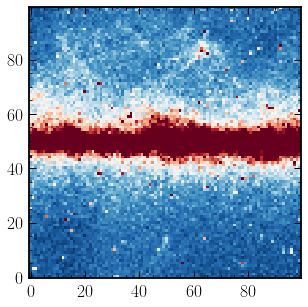

In [12]:
plt.imshow(counts_downsampled, vmax=100, cmap=cmap, origin='lower')

## Templates

In [13]:
extent = 25
n_pixels = 100
pixelsize = 2 * extent / n_pixels
upsample_factor = 4
nside = 128
sigma_psf = 0.2

In [14]:
pixelsize

0.5

In [15]:
fermi_data_cart = to_cart(np.load("../data/fermi_data/fermidata_counts.npy"), n_pixels=n_pixels, pixelsize=pixelsize)

# Load standard templates
temp_gce_cart = to_cart(np.load("../data/fermi_data/template_gce.npy"), n_pixels=n_pixels, pixelsize=pixelsize)
temp_dif_cart = to_cart(np.load("../data/fermi_data/template_dif.npy"), n_pixels=n_pixels, pixelsize=pixelsize)
temp_psc_cart = to_cart(np.load("../data/fermi_data/template_psc.npy"), n_pixels=n_pixels, pixelsize=pixelsize)
temp_iso_cart = to_cart(np.load("../data/fermi_data/template_iso.npy"), n_pixels=n_pixels, pixelsize=pixelsize)
temp_dsk_cart = to_cart(np.load("../data/fermi_data/template_dsk.npy"), n_pixels=n_pixels, pixelsize=pixelsize)
temp_bub_cart = to_cart(np.load("../data/fermi_data/template_bub.npy"), n_pixels=n_pixels, pixelsize=pixelsize)
mask_ps = np.load("../data/fermi_data/fermidata_pscmask.npy") == 1

# Load Model O templates
temp_mO_pibrem_cart = to_cart(np.load("../data/fermi_data/ModelO_r25_q1_pibrem.npy"), n_pixels=n_pixels, pixelsize=pixelsize)
temp_mO_ics_cart = to_cart(np.load("../data/fermi_data/ModelO_r25_q1_ics.npy"), n_pixels=n_pixels, pixelsize=pixelsize)

mask_roi = to_cart(cm.make_mask_total(nside=nside, band_mask=True, band_mask_range=2., mask_ring=True, inner=0, outer=60., custom_mask=mask_ps), n_pixels=n_pixels, pixelsize=pixelsize) > 0
# mask_roi = to_cart(cm.make_mask_total(nside=nside, band_mask=True, band_mask_range=2., mask_ring=True, inner=0, outer=60.,), n_pixels=n_pixels, pixelsize=pixelsize) > 0


## Fit to real data

In [ ]:
from jax import random
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist
from numpyro.distributions import constraints
from numpyro.infer import Predictive, SVI, Trace_ELBO, RenyiELBO
from numpyro.infer.autoguide import AutoIAFNormal, AutoMultivariateNormal, AutoDiagonalNormal, AutoLaplaceApproximation, AutoBNAFNormal
from jax.lax import scan
import jax.lax as lax

def model(data, rng_key=random.PRNGKey(13)):
    
    theta_gce = numpyro.sample("theta_gce", dist.Uniform(0., 20.), rng_key=rng_key)
    theta_iso = numpyro.sample("theta_iso", dist.Uniform(0., 20.), rng_key=rng_key)
    theta_bub = numpyro.sample("theta_bub", dist.Uniform(0., 20.), rng_key=rng_key)
    theta_psc = numpyro.sample("theta_psc", dist.Uniform(0., 20.), rng_key=rng_key)
    theta_pibrem = numpyro.sample("theta_pibrem", dist.Uniform(0., 40.), rng_key=rng_key)
    theta_ics = numpyro.sample("theta_ics", dist.Uniform(0., 20.), rng_key=rng_key)
    
    mu = temp_gce_cart * theta_gce + \
        temp_iso_cart * theta_iso + \
        temp_bub_cart * theta_bub + \
        temp_psc_cart * theta_psc + \
        temp_mO_pibrem_cart * theta_pibrem + \
        temp_mO_ics_cart * theta_ics
    
    
    data = data.reshape(-1, data.shape[-1] * data.shape[-2])
    mu = mu.reshape(-1, data.shape[-1] * data.shape[-2])
    
    with numpyro.plate("data_plate", data.shape[-1]):
        return numpyro.sample("obs", dist.Poisson(mu), obs=data, rng_key=rng_key)


/n/home11/smsharma/.conda/envs/deepsets/lib/python3.9/site-packages/jax/experimental/optimizers.py:28: FutureWarning: jax.experimental.optimizers is deprecated, import jax.example_libraries.optimizers instead
  warnings.warn('jax.experimental.optimizers is deprecated, '
/n/home11/smsharma/.conda/envs/deepsets/lib/python3.9/site-packages/jax/experimental/stax.py:28: FutureWarning: jax.experimental.stax is deprecated, import jax.example_libraries.stax instead
  warnings.warn('jax.experimental.stax is deprecated, '


In [73]:
from numpyro.infer import MCMC, HMC, NUTS

kernel = NUTS(model, target_accept_prob=0.9)
mcmc = MCMC(kernel, num_warmup=1000, num_samples=3200)
mcmc.run(rng_key=random.PRNGKey(0), data=counts_downsampled)

mcmc.print_summary()

sample: 100%|█| 4200/4200 [00:46<00:00, 90.53it/s, 15 steps of size 3.21e-01. acc. prob=



                    mean       std    median      5.0%     95.0%     n_eff     r_hat
     theta_bub      0.65      0.04      0.65      0.58      0.71   2647.21      1.00
     theta_gce      2.49      0.06      2.49      2.39      2.59   2555.06      1.00
     theta_ics      6.54      0.10      6.54      6.37      6.70   2333.48      1.00
     theta_iso      0.01      0.01      0.00      0.00      0.01   3595.91      1.00
  theta_pibrem     19.87      0.06     19.87     19.77     19.97   2714.45      1.00
     theta_psc      0.20      0.01      0.20      0.18      0.21   3009.03      1.00

Number of divergences: 0


## Sims

In [39]:
mesh_dim = np.linspace(0, n_pixels, (n_pixels + 1) * upsample_factor)
interp = RectBivariateSpline(np.arange(n_pixels), np.arange(n_pixels), temp_gce_cart)
temp_gce_cart_upsampled = interp(mesh_dim, mesh_dim)

In [40]:
from models.scd import dnds

In [41]:
n_sim = 500

prior_ps = [[0.001, 10.0, 1.1, -10.0, 5.0, 1., 0.001, 10.0, 1.1, -10.0, 5.0, 1.], 
            [2., 20.0, 1.99, 1.99, 40.0, 4.99, 2., 20.0, 1.99, 1.99, 40.0, 4.99]]

prior_poiss = [[0.001, 0.001, 0.001, 0.001, 16.0, 6.0], 
               [2., 1.5, 1., 1., 21.0, 7.0]]

temps_ps = np.array([temp_gce_cart, temp_dsk_cart])
temps_poiss = np.array([temp_gce_cart, temp_iso_cart, temp_bub_cart, temp_psc_cart, temp_mO_pibrem_cart, temp_mO_ics_cart])

temps_ps_upsampled = []

for temp_ps in temps_ps:
    interp = RectBivariateSpline(np.arange(n_pixels), np.arange(n_pixels), temp_ps)
    temp_ps_upsampled = interp(mesh_dim, mesh_dim)
    temps_ps_upsampled.append(temp_ps_upsampled)

thetas = np.random.uniform(low=prior_poiss[0] + prior_ps[0], high=prior_poiss[1] + prior_ps[1], size=(n_sim, len(prior_ps[0]) + len(prior_poiss[0])))

In [42]:
s_ary = np.logspace(-1, 2, 1000)
logs_ary = np.log10(s_ary)
dlogs_ary = np.diff(logs_ary)[0] # Spacing in log-space

s_for_ds_ary = np.logspace(logs_ary[0] - dlogs_ary / 2.0, logs_ary[-1] + dlogs_ary / 2.0, len(s_ary) + 1)
ds_ary = np.diff(s_for_ds_ary)

signal_ensemble = np.zeros((n_sim, n_pixels, n_pixels))
flux_fraction = np.zeros((n_sim, len(temps_ps) + len(temps_poiss)))
dnds_ary = []

for idx_theta, theta in enumerate(tqdm(thetas)):

    idx_theta_ps = len(temps_poiss)
    
    for idx, temp_ps in enumerate(temps_ps):

        dnds_ary_temp = dnds(s_ary, theta[idx_theta_ps:idx_theta_ps + 6])
        s_exp = np.trapz(s_ary * dnds_ary_temp, s_ary)
        dnds_ary_temp *= theta[idx_theta_ps] * np.prod(temp_ps.shape) / s_exp
        dnds_ary.append(dnds_ary_temp)
        idx_theta_ps += 6

        n_ps = np.random.poisson(np.trapz(dnds_ary_temp, s_ary))

        # Sample, accounting for dS factor for log-space sampling
        sample = PDFSampler(s_ary, ds_ary * dnds_ary_temp)(n_ps)

        dist = temps_ps_upsampled[idx]
        dist /= dist.sum() 
        pairs = np.indices(dimensions=temps_ps_upsampled[idx].shape).T # here are all of the x,y pairs 
        inds = np.random.choice(np.arange(np.prod(temps_ps_upsampled[idx].shape)),p=dist.reshape(-1),size=n_ps,replace=True)
        selections = pairs.reshape(-1, 2)[inds]
        hist = np.histogram2d(x=selections[:, 1], y=selections[:, 0], bins=n_pixels * upsample_factor, weights=sample)[0]
        
        signal = np.random.poisson(gaussian_filter(hist, sigma=sigma_psf / (pixelsize / upsample_factor), truncate=8.))

        b = signal.shape[0] // upsample_factor
        signal_reshaped = signal.reshape(-1, upsample_factor, b, upsample_factor).sum((-1, -3))

        signal_ensemble[idx_theta, :, :] += signal_reshaped
        
        flux_fraction[idx_theta, idx] = signal_reshaped.mean()
        
    flux_fraction[idx_theta, 2:] = (temps_poiss.T * theta[:len(temps_poiss)]).mean((0,1))
    signal_ensemble[idx_theta, :, :] += np.random.poisson(np.einsum('i,ijk->jk', theta[:len(temps_poiss)], temps_poiss))
    
flux_fraction = (flux_fraction.T / flux_fraction.sum(1)).T

  0%|          | 0/500 [00:00<?, ?it/s]

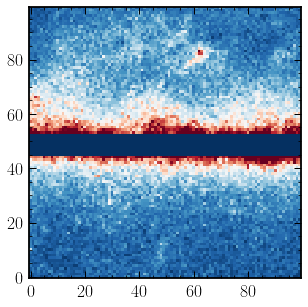

In [117]:
plt.imshow(signal_ensemble[2] * ~mask_roi, vmin=0, vmax=100, origin='lower', cmap=cmap)

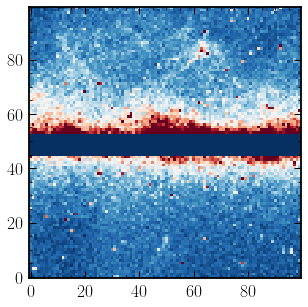

In [118]:
plt.imshow(counts_downsampled * ~mask_roi, vmax=100, cmap=cmap, origin='lower')

In [119]:
np.savez("../data/samples/data_uniform.npz", signal_ensemble=signal_ensemble, flux_fraction=flux_fraction)

In [43]:
np.savez("../data/samples/data_uniform_test.npz", signal_ensemble=signal_ensemble, flux_fraction=flux_fraction)

## Generative model

In [16]:
data = np.load("../data/samples/data_uniform.npz")
signal_ensemble = data["signal_ensemble"]
flux_fraction = data["flux_fraction"]

In [17]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data as data
import torch.optim as optim

import pytorch_lightning as pl
from pytorch_lightning.callbacks import LearningRateMonitor, ModelCheckpoint, EarlyStopping

from models.glow import Glow
from models.glow.module import GlowPL

In [18]:
from torch.utils.data import TensorDataset, DataLoader, random_split, SubsetRandomSampler

In [19]:
x = torch.Tensor(signal_ensemble).unsqueeze(1)
y = torch.Tensor(flux_fraction)

In [20]:
x.max()

tensor(2966.)

In [21]:
x = x[:, :, 2:-2, 2:-2] 

val_fraction = 0.10
n_samples_val = int(val_fraction * len(x))

dataset = TensorDataset(x, y)

dataset_train, dataset_val = random_split(dataset, [len(x) - n_samples_val, n_samples_val])
train_loader = DataLoader(dataset_train, batch_size=128, num_workers=0, pin_memory=False, shuffle=True)
val_loader = DataLoader(dataset_val, batch_size=128, num_workers=0, pin_memory=False, shuffle=False)

In [22]:
model = GlowPL(num_channels=256, num_levels=5, num_steps=18, quants=x.max() + 1)

In [23]:
model.flow.load_state_dict(torch.load("../data/logs/wandb/run-20220330_045649-45qx9i8l/files/flow.ckpt"))
model.flow.eval();

In [49]:
# checkpoint_callback = ModelCheckpoint(monitor="val_loss")
# lr_monitor = LearningRateMonitor(logging_interval='epoch')

# trainer = pl.Trainer(max_epochs=100, gpus=1, gradient_clip_val=1., callbacks=[checkpoint_callback, lr_monitor])
# trainer.fit(model=model, train_dataloaders=train_loader, val_dataloaders=val_loader)

# model.load_from_checkpoint(checkpoint_callback.best_model_path, num_channels=256, num_leveload_state_dict, num_steps=18, quants=x.max() + 1);

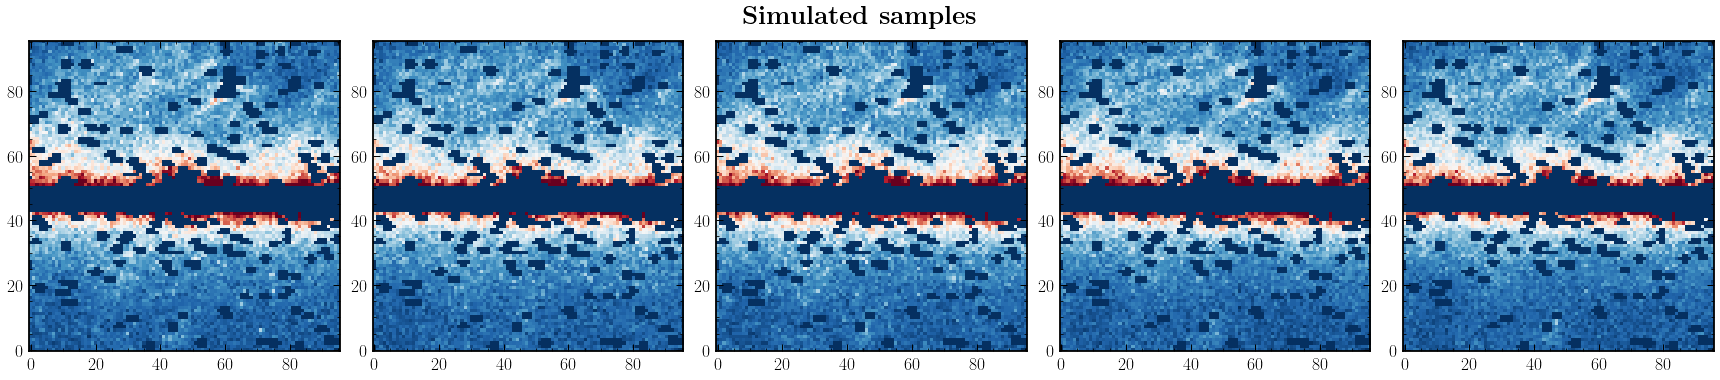

In [28]:
fig, axs = plt.subplots(1, 5, figsize=(16 * 1.5, 4 * 1.5))

for i, ax in enumerate(axs):
    ax.imshow(x[i,0].detach().numpy() * ~mask_roi[2:-2, 2:-2] , cmap=cmap, vmax=100, origin='lower')
    
plt.suptitle(r"\textbf{Simulated samples}", fontsize=26, y=0.9)
plt.tight_layout()

In [29]:
z = torch.randn(size=(5, 1, 96, 96))
x_samples, sldj = model.flow(z, reverse=True)

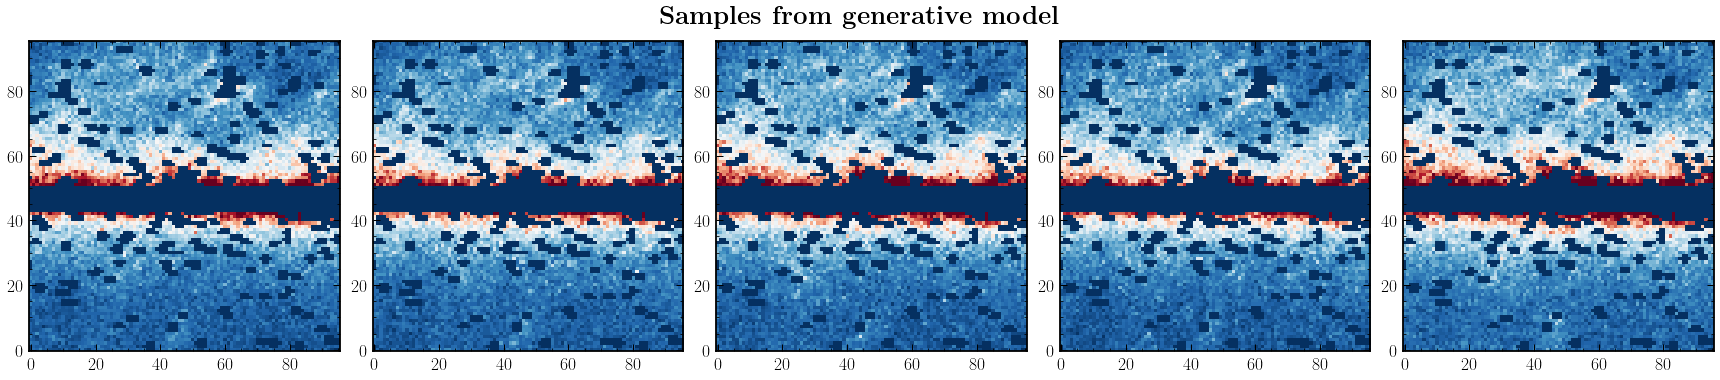

In [30]:
fig, axs = plt.subplots(1, 5, figsize=(16 * 1.5, 4 * 1.5))

for i, ax in enumerate(axs):
    ax.imshow(x_samples[i,0].detach().numpy() * ~mask_roi[2:-2, 2:-2], cmap=cmap, vmax=100, origin='lower')
    
plt.suptitle(r"\textbf{Samples from generative model}", fontsize=26, y=0.9)
plt.tight_layout()

## Test summaries

In [32]:
x_samples = torch.zeros(500, 1, 96, 96)
for i in tqdm(range(500)):
    z = torch.randn(size=(1, 1, 96, 96))
    x_samples[i, :] = model.flow(z, reverse=True)[0][0]

  0%|          | 0/500 [00:00<?, ?it/s]

In [33]:
from scipy import stats

def power_spectrum(x):
    """ Power spectrum of map. Adapted from https://bertvandenbroucke.netlify.app/2019/05/24/computing-a-power-spectrum-in-python/
    """
    
    npix = x.shape[0]

    fourier_image = np.fft.fftn(x)
    fourier_amplitudes = np.abs(fourier_image)**2

    kfreq = np.fft.fftfreq(npix) * npix
    kfreq2D = np.meshgrid(kfreq, kfreq)
    knrm = np.sqrt(kfreq2D[0]**2 + kfreq2D[1]**2)

    knrm = knrm.flatten()
    fourier_amplitudes = fourier_amplitudes.flatten()

    kbins = np.arange(0.5, npix//2+1, 1.)
    kvals = 0.5 * (kbins[1:] + kbins[:-1])
    Abins, _, _ = stats.binned_statistic(knrm, fourier_amplitudes,
                                         statistic = "mean",
                                         bins = kbins)
    Abins *= np.pi * (kbins[1:]**2 - kbins[:-1]**2)
    
    return Abins

def counts_histogram(x, counts_max=128):
    bins_hist = np.arange(counts_max)
    return np.histogram(x, bins=bins_hist)[0]

In [34]:
x_pspec_samples = np.array([power_spectrum(x_i) for x_i in x_samples[:, 0, :, :]])
x_pspec_train = np.array([power_spectrum(x_i) for x_i in x[:500, 0]])

x_hist_samples = np.array([counts_histogram(x_i) for x_i in x_samples])
x_hist_train = np.array([counts_histogram(x_i) for x_i in x[:500, 0]])

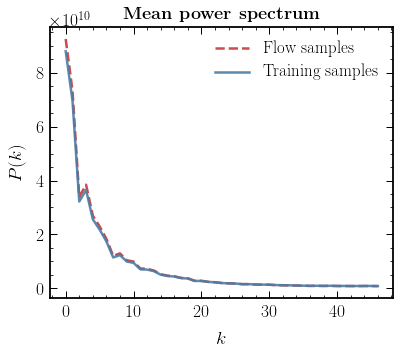

In [35]:
plt.plot(np.nanmean(x_pspec_samples, axis=0)[1:], label="Flow samples", ls='--')
plt.plot(np.mean(x_pspec_train, axis=0)[1:], label="Training samples")

plt.xlabel("$k$")
plt.ylabel("$P(k)$")
plt.title(r"\textbf{Mean power spectrum}")
         
plt.legend()

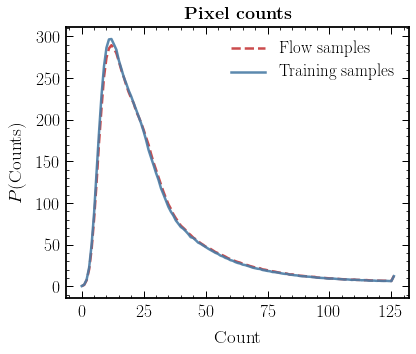

In [36]:
plt.plot(np.nanmean(x_hist_samples, axis=0), label="Flow samples", ls='--')
plt.plot(np.mean(x_hist_train, axis=0), label="Training samples")

plt.xlabel("Count")
plt.ylabel("$P(\mathrm{Counts})$")
plt.title(r"\textbf{Pixel counts}")
         
plt.legend()

In [146]:
from pytorch_wavelets import DWTForward, DWTInverse

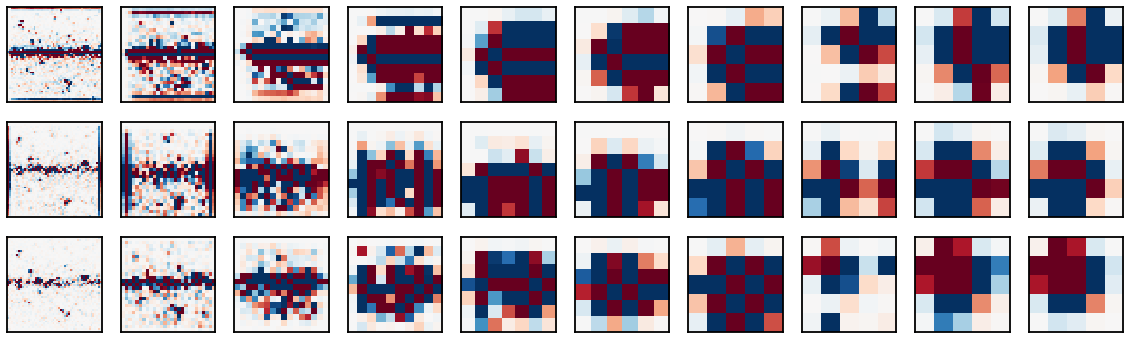

In [164]:
fig, axs = plt.subplots(3, 10, figsize=(20, 6))

xfm = DWTForward(J=10, wave='db3', mode='zero')
Yl, Yh = xfm(x[:500])

for i in range(3):
    for j in range(10):        
        axs[i, j].imshow(Yh[j].mean((0,1))[i], cmap=cmap, vmin=-10, vmax=10)
        axs[i, j].get_xaxis().set_visible(False)
        axs[i, j].get_yaxis().set_visible(False)

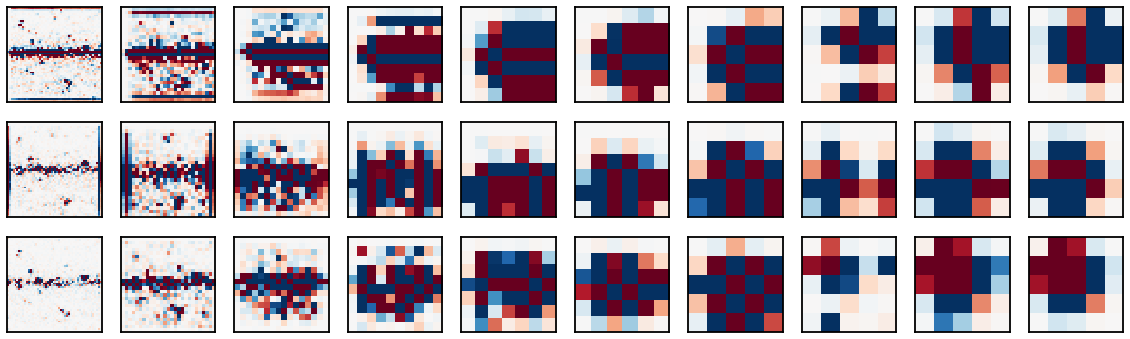

In [165]:
fig, axs = plt.subplots(3, 10, figsize=(20, 6))

xfm = DWTForward(J=10, wave='db3', mode='zero')
Yl, Yh = xfm(x_samples)

for i in range(3):
    for j in range(10):        
        axs[i, j].imshow(Yh[j].mean((0,1))[i], cmap=cmap, vmin=-10, vmax=10)
        axs[i, j].get_xaxis().set_visible(False)
        axs[i, j].get_yaxis().set_visible(False)

## Interpolating in the latent space

In [170]:
def z_interp(z1, z2, weight=0.5):
    z_interp = torch.lerp(z1, z2, weight)
    return z_interp

In [171]:
z, _ = model.flow(x[5:7])

In [176]:
vrange = 100

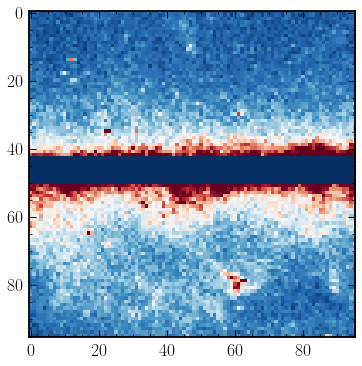

In [177]:
from celluloid import Camera

n_interp = 100

weights_ary = np.linspace(0, 1, n_interp)

fig = plt.figure(figsize=(6,6))

camera = Camera(fig)

for i in range(n_interp):
    
    x_dec = model.flow(z_interp(z[0], z[1], weight=weights_ary[i]).unsqueeze(0), reverse=True)[0]
    
    plt.imshow(x_dec[0,0].detach().numpy() * ~mask_roi[2:-2, 2:-2], cmap=cmap, vmin=0, vmax=vrange)
    
    camera.snap()

In [178]:
animation = camera.animate()

In [179]:
from IPython.display import HTML
HTML(animation.to_html5_video())

In [45]:
animation.save('latent_interp.gif', fps=15)

## Inference network

In [24]:
from models.resnet import ResNetEstimator

In [25]:
# rn = ResNetEstimator(n_out=8)
# torch.softmax(rn(x[:64, 0]), dim=-1)

In [26]:
class ResnetPL(pl.LightningModule):

    def __init__(self, mask=None, lr=3e-4, optimizer_kwargs={'weight_decay': 1e-5}, scheduler='plateau', scheduler_kwargs={'patience':4}):
        """
        Inputs:
            flows - A list of flows (each a nn.Module) that should be applied on the images.
        """
        super().__init__()
        self.resnet = ResNetEstimator(n_out=int(2 * 8))
        self.loss = nn.GaussianNLLLoss(reduction='mean')
        self.lr = lr
        self.optimizer_kwargs = optimizer_kwargs
        
        self.mask = torch.from_numpy(mask).to('cuda')
        
        self.optimizer = torch.optim.AdamW(self.parameters(), lr=self.lr, **optimizer_kwargs)

        if scheduler == "cosine":
            self.scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(self.optimizer, **scheduler_kwargs)
        elif scheduler == "plateau":
            self.scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(self.optimizer, **scheduler_kwargs)
        else:
            raise NotImplementedError

    def configure_optimizers(self):
        
        return {"optimizer": self.optimizer, 
                    "lr_scheduler": {
                    "scheduler": self.scheduler,
                    "interval": "epoch",
                    "monitor": "val_loss",
                    "frequency": 1}
                }
    def training_step(self, batch, batch_idx):
        x, y = batch
        x += 1e-6
        x = torch.log10(x)
        out = self.resnet(x[:, 0] * ~self.mask)
        mu, logvar = torch.chunk(out, 2, -1)
        mu = torch.softmax(mu, dim=-1)
        loss = self.loss(mu, y, logvar.exp())
        self.log('train_loss', loss)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        x += 1e-6
        x = torch.log10(x)
        out = self.resnet(x[:, 0] * ~self.mask)
        mu, logvar = torch.chunk(out, 2, -1)
        mu = torch.softmax(mu, dim=-1)
        loss = self.loss(mu, y, logvar.exp())
        self.log('val_loss', loss)

In [27]:
x_mean = 0  # x.mean()
x_std = 1  # x.std()

x_train = (x - x_mean) / x_std
y_train = y

In [28]:
val_fraction = 0.10
n_samples_val = int(val_fraction * len(x_train))

dataset = TensorDataset(x_train, y_train)

dataset_train, dataset_val = random_split(dataset, [len(x_train) - n_samples_val, n_samples_val])
train_loader = DataLoader(dataset_train, batch_size=128, num_workers=0, pin_memory=False, shuffle=True)
val_loader = DataLoader(dataset_val, batch_size=128, num_workers=0, pin_memory=False, shuffle=False)

In [29]:
model_inference = ResnetPL(mask=mask_roi[2:-2, 2:-2])

In [65]:
checkpoint_callback = ModelCheckpoint(monitor="val_loss")
lr_monitor = LearningRateMonitor(logging_interval='epoch')

trainer = pl.Trainer(max_epochs=25, gpus=1, gradient_clip_val=1., callbacks=[checkpoint_callback, lr_monitor])
trainer.fit(model=model_inference, train_dataloaders=train_loader, val_dataloaders=val_loader)

model_inference.load_from_checkpoint(checkpoint_callback.best_model_path, mask=mask_roi[2:-2, 2:-2]);

GPU available: True, used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Set SLURM handle signals.

  | Name   | Type            | Params
-------------------------------------------
0 | resnet | ResNetEstimator | 12.3 M
1 | loss   | GaussianNLLLoss | 0     
-------------------------------------------
12.3 M    Trainable params
0         Non-trainable params
12.3 M    Total params
49.015    Total estimated model params size (MB)
/n/home11/smsharma/.conda/envs/deepsets/lib/python3.9/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:631: UserWarning: Checkpoint directory /net/rcstorenfs02/ifs/rc_labs/dvorkin_lab/smsharma/mi-attribution/notebooks/lightning_logs/version_3034187/checkpoints exists and is not empty.
  rank_zero_warn(f"Checkpoint directory {dirpath} exists and is not empty.")


Validation sanity check: 0it [00:00, ?it/s]

/n/home11/smsharma/.conda/envs/deepsets/lib/python3.9/site-packages/pytorch_lightning/trainer/data_loading.py:132: UserWarning: The dataloader, val_dataloader 0, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 32 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(
/n/home11/smsharma/.conda/envs/deepsets/lib/python3.9/site-packages/pytorch_lightning/trainer/data_loading.py:132: UserWarning: The dataloader, train_dataloader, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 32 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(


Training: 0it [00:00, ?it/s]

Validating: 0it [00:00, ?it/s]

...

Validating: 0it [00:00, ?it/s]

Validating: 0it [00:00, ?it/s]

Validating: 0it [00:00, ?it/s]

Validating: 0it [00:00, ?it/s]

Validating: 0it [00:00, ?it/s]

In [66]:
model_inference.eval();

In [67]:
data = np.load("../data/samples/data_uniform_test.npz")
signal_ensemble = data["signal_ensemble"]
flux_fraction = data["flux_fraction"]

x_test = torch.Tensor(signal_ensemble).unsqueeze(1)
y_test = torch.Tensor(flux_fraction)

x_test = x_test[:, :, 2:-2, 2:-2] 

In [68]:
y_true = flux_fraction[:256]
out = model_inference.resnet(((x_test[:256, 0] + 1e-6).log10() - x_mean) / x_std * ~mask_roi[2:-2, 2:-2])
mu, logvar = torch.chunk(out, 2, -1)
mu = torch.softmax(mu, dim=-1)

In [69]:
mu

tensor([[0.0263, 0.0041, 0.0340,  ..., 0.0184, 0.7471, 0.1514],
        [0.0388, 0.0112, 0.0505,  ..., 0.0207, 0.6908, 0.1661],
        [0.0036, 0.0037, 0.0484,  ..., 0.0183, 0.7488, 0.1613],
        ...,
        [0.0216, 0.0173, 0.0309,  ..., 0.0190, 0.7389, 0.1567],
        [0.0394, 0.0200, 0.0137,  ..., 0.0208, 0.7072, 0.1734],
        [0.0323, 0.0085, 0.0357,  ..., 0.0186, 0.7233, 0.1461]],
       grad_fn=<SoftmaxBackward0>)

  0%|          | 0/8 [00:00<?, ?it/s]

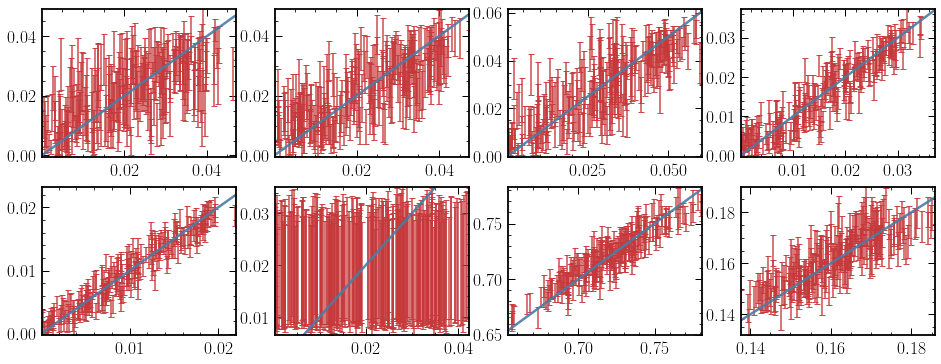

In [70]:
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(16, 6))
gs = GridSpec(2, 4)

for i in tqdm(range(8)):
    
    ax = fig.add_subplot(gs[i])
    ax.errorbar(y_true[:, i], mu[:, i].detach().numpy(), yerr=logvar[:, i].exp().sqrt().detach().numpy(), fmt='none', capsize=3, capthick=1, elinewidth=1.5)
    ax.plot([0., 1],[0., 1])
    
    ax.set_xlim(np.min(y_true[:, i]), np.max(y_true[:, i]))
    ax.set_ylim(np.min(mu[:, i].detach().numpy() - logvar[:, i].exp().sqrt().detach().numpy()), np.max(mu[:, i].detach().numpy() + logvar[:, i].exp().sqrt().detach().numpy()))

## Counterfactuals

In [71]:
from torch.autograd.functional import vjp, jvp, jacobian

In [84]:
x0 = x_test[3].unsqueeze(0)
z0, _ = model.flow(x0)

out = model_inference.resnet(((x0[0] + 1e-6).log10() - x_mean) / x_std * torch.Tensor(~mask_roi[2:-2, 2:-2]))
mu, logvar = torch.chunk(out, 2, -1)
mu = torch.softmax(mu, dim=-1)

In [85]:
mu

tensor([[0.0246, 0.0257, 0.0268, 0.0147, 0.0090, 0.0203, 0.7140, 0.1648]],
       grad_fn=<SoftmaxBackward0>)

In [86]:
logvar.exp().sqrt()

tensor([[0.0103, 0.0083, 0.0099, 0.0034, 0.0017, 0.0119, 0.0096, 0.0066]],
       grad_fn=<SqrtBackward0>)

In [87]:
z_detached = z0.detach()
z_detached.requires_grad = True
# z_detached.retain_grad()

def objective(z):
    return torch.softmax(model_inference.resnet(((model.flow(z, reverse=True, quant_int=False)[0] + 1e-6 - x_mean).log10() / x_std)[0] * torch.Tensor(~mask_roi[2:-2, 2:-2]))[:, :8], dim=-1)[0, 0]

jacobian(objective, z_detached)

tensor([[[[ 6.3535e-05, -9.5672e-06, -9.2216e-05,  ...,  1.0509e-05,
           -2.1253e-05,  1.5409e-05],
          [-1.5653e-05,  2.9212e-06,  3.1034e-05,  ...,  2.1316e-05,
            8.7886e-06, -1.4220e-05],
          [ 6.2155e-05,  3.3466e-06,  7.4919e-05,  ..., -6.1272e-05,
           -2.1513e-05, -4.7250e-05],
          ...,
          [-3.8362e-07, -5.5141e-06,  1.9068e-05,  ..., -1.3793e-05,
           -5.1426e-06,  1.8415e-05],
          [-8.0713e-07, -2.2878e-05,  1.0364e-06,  ...,  2.4323e-05,
            1.2629e-05,  4.6609e-05],
          [ 5.0240e-06, -1.0879e-05, -1.9345e-06,  ...,  2.7819e-06,
           -1.6426e-05,  3.6741e-06]]]])

In [88]:
model_inference.to('cpu')
model.to('cpu');

In [89]:
class DiffeomorphicConfounder(torch.nn.Module):
    def __init__(self, z0):
        """
        In the constructor we instantiate four parameters and assign them as
        member parameters.
        """
        super().__init__()
        self.z = torch.nn.Parameter(z0)

    def forward(self, param_idx=0):
        """
        In the forward function we accept a Tensor of input data and we must return
        a Tensor of output data. We can use Modules defined in the constructor as
        well as arbitrary operators on Tensors.
        """
        return torch.softmax(model_inference.resnet(((model.flow(self.z.unsqueeze(0).unsqueeze(0), reverse=True, quant_int=False)[0] + 1e-6 - x_mean).log10() / x_std)[0] * torch.Tensor(~mask_roi[2:-2, 2:-2]))[:, :8], dim=-1)[0, param_idx]

In [90]:
dc = DiffeomorphicConfounder(z0[0,0])

optimizer = torch.optim.SGD(dc.parameters(), lr=0.1)

condition = True

i = 0
i_param = 1

while condition:

    y_pred = dc(i_param)
    
    print(y_pred)
        
    optimizer.zero_grad()
    y_pred.backward()
    optimizer.step()
    
    condition = y_pred > (mu - logvar.exp().sqrt())[0, i_param]
    i += 1

tensor(0.0229, grad_fn=<SelectBackward0>)
tensor(0.0229, grad_fn=<SelectBackward0>)
tensor(0.0228, grad_fn=<SelectBackward0>)
tensor(0.0228, grad_fn=<SelectBackward0>)
tensor(0.0227, grad_fn=<SelectBackward0>)
tensor(0.0227, grad_fn=<SelectBackward0>)
tensor(0.0226, grad_fn=<SelectBackward0>)
tensor(0.0226, grad_fn=<SelectBackward0>)
tensor(0.0225, grad_fn=<SelectBackward0>)
tensor(0.0225, grad_fn=<SelectBackward0>)
tensor(0.0224, grad_fn=<SelectBackward0>)
tensor(0.0224, grad_fn=<SelectBackward0>)
tensor(0.0223, grad_fn=<SelectBackward0>)
tensor(0.0223, grad_fn=<SelectBackward0>)
tensor(0.0222, grad_fn=<SelectBackward0>)
tensor(0.0222, grad_fn=<SelectBackward0>)
tensor(0.0221, grad_fn=<SelectBackward0>)
tensor(0.0221, grad_fn=<SelectBackward0>)
tensor(0.0220, grad_fn=<SelectBackward0>)
tensor(0.0220, grad_fn=<SelectBackward0>)
tensor(0.0219, grad_fn=<SelectBackward0>)
tensor(0.0219, grad_fn=<SelectBackward0>)
tensor(0.0218, grad_fn=<SelectBackward0>)
tensor(0.0218, grad_fn=<SelectBack

In [91]:
x_cf = model.flow(dc.z.unsqueeze(0).unsqueeze(0), reverse=True)[0][0,0].detach().numpy()

In [92]:
torch.softmax(model_inference.resnet(((x0[0] + 1e-6 - x_mean).log10() / x_std * ~mask_roi[2:-2, 2:-2]))[:, :8], dim=-1)

tensor([[0.0246, 0.0257, 0.0268, 0.0147, 0.0090, 0.0203, 0.7140, 0.1648]],
       grad_fn=<SoftmaxBackward0>)

In [93]:
torch.softmax(model_inference.resnet(((torch.Tensor(x_cf).unsqueeze(0) + 1e-6 - x_mean).log10() / x_std * ~mask_roi[2:-2, 2:-2]))[:, :8], dim=-1)

tensor([[0.0294, 0.0200, 0.0256, 0.0157, 0.0088, 0.0203, 0.7152, 0.1650]],
       grad_fn=<SoftmaxBackward0>)

Text(0.5, 1.0, '\\bf{Difference}')

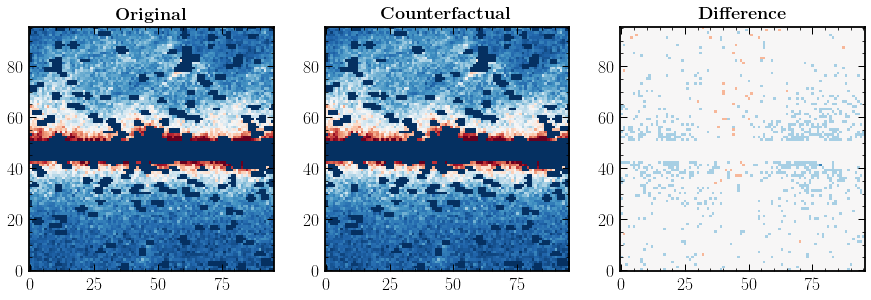

In [94]:
fig, axs = plt.subplots(1, 3, figsize=(10 * 1.5, 3 * 1.5))
vrange = 100

axs[0].imshow(x0[0,0].detach().numpy() * ~mask_roi[2:-2, 2:-2], cmap=cmap, vmin=0, vmax=vrange, origin='lower')
axs[0].set_title(r"\bf{Original}")

axs[1].imshow(x_cf * ~mask_roi[2:-2, 2:-2], cmap=cmap, vmin=0, vmax=vrange, origin='lower')
axs[1].set_title(r"\bf{Counterfactual}")

axs[2].imshow((x_cf - x0[0,0].detach().numpy()) * ~mask_roi[2:-2, 2:-2], cmap=cmap, vmin=-3, vmax=3, origin='lower')
axs[2].set_title(r"\bf{Difference}")

/tmp/ipykernel_48415/1597661811.py:3: RuntimeWarning: invalid value encountered in true_divide
  plot = plt.imshow(np.abs(x_cf - x0[0,0].detach().numpy()) / np.sqrt(x0[0,0].detach().numpy()) * ~mask_roi[2:-2, 2:-2], cmap=cmap, vmin=0, vmax=1, origin='lower')


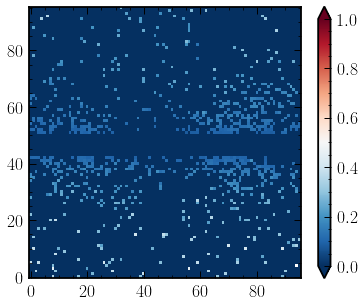

In [95]:
fig, ax = plt.subplots()

plot = plt.imshow(np.abs(x_cf - x0[0,0].detach().numpy()) / np.sqrt(x0[0,0].detach().numpy()) * ~mask_roi[2:-2, 2:-2], cmap=cmap, vmin=0, vmax=1, origin='lower')

cbar = fig.colorbar(plot, ax=plt.gca(), extend='both')
cbar.minorticks_on()
plt.show()